In [ ]:
# Binary Skin Cancer Classification (Malignant vs Benign)

In [3]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split


In [4]:
BASE_DIR = "dataset/HAM10000"
IMG_DIRS = [
    os.path.join(BASE_DIR, "HAM10000_images_part_1"),
    os.path.join(BASE_DIR, "HAM10000_images_part_2")
]

CSV_PATH = os.path.join(BASE_DIR, "HAM10000_metadata.csv")

OUTPUT_DIR = "HAM_BINARY"


In [5]:
splits = ["train", "val", "test"]
classes = ["Benign", "Malignant"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

print("Folder structure created.")


Folder structure created.


In [6]:
df = pd.read_csv(CSV_PATH)

print(df.head())
print("Total images:", len(df))


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

        dataset  
0  vidir_modern  
1  vidir_modern  
2  vidir_modern  
3  vidir_modern  
4  vidir_modern  
Total images: 10015


In [7]:
df["binary_label"] = df["dx"].apply(
    lambda x: "Malignant" if x == "mel" else "Benign"
)

df["image_name"] = df["image_id"] + ".jpg"

df[["image_name", "dx", "binary_label"]].head()


,image_name,dx,binary_label
0,ISIC_0027419.jpg,bkl,Benign
1,ISIC_0025030.jpg,bkl,Benign
2,ISIC_0026769.jpg,bkl,Benign
3,ISIC_0025661.jpg,bkl,Benign
4,ISIC_0031633.jpg,bkl,Benign


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["binary_label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["binary_label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7010
Val: 1502
Test: 1503


In [9]:
def find_image(image_name):
    for img_dir in IMG_DIRS:
        path = os.path.join(img_dir, image_name)
        if os.path.exists(path):
            return path
    return None


In [10]:
def copy_images(df_split, split_name):
    for _, row in df_split.iterrows():
        src = find_image(row["image_name"])
        if src is None:
            continue
        
        dst = os.path.join(
            OUTPUT_DIR,
            split_name,
            row["binary_label"],
            row["image_name"]
        )
        shutil.copy(src, dst)

    print(f"{split_name} images copied.")


In [11]:
copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")


train images copied.
val images copied.
test images copied.


In [12]:
for split in ["train", "val", "test"]:
    for cls in ["Benign", "Malignant"]:
        path = os.path.join(OUTPUT_DIR, split, cls)
        print(split, cls, len(os.listdir(path)))


train Benign 6231
train Malignant 779
val Benign 1335
val Malignant 167
test Benign 1336
test Malignant 167


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


In [15]:
BASE_DIR = "HAM_BINARY"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [17]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 7010 images belonging to 2 classes.
Found 1502 images belonging to 2 classes.
Found 1503 images belonging to 2 classes.


In [18]:
print("Class mapping:", train_generator.class_indices)


Class mapping: {'Benign': 0, 'Malignant': 1}


In [19]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])


/opt/anaconda3/envs/skinscan/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [21]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [23]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 169s 758ms/step - accuracy: 0.8397 - loss: 3.2737 - val_accuracy: 0.8888 - val_loss: 3.6768 - learning_rate: 0.0010
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.8686 - loss: 1.0049 - val_accuracy: 0.8888 - val_loss: 0.3984 - learning_rate: 0.0010
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.8802 - loss: 0.9044 - val_accuracy: 0.8881 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.8807 - loss: 0.9407 - val_accuracy: 0.7989 - val_loss: 0.7625 - learning_rate: 0.0010
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.8797 - loss: 0.4988
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
220/220 ━━━━━━━━━━━━━━━━━━━━ 178s 807ms/step - accuracy: 0.8837 - loss: 0.4686 - val_accuracy: 0.8888 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 171s 776ms/step - accuracy: 0.8877 -

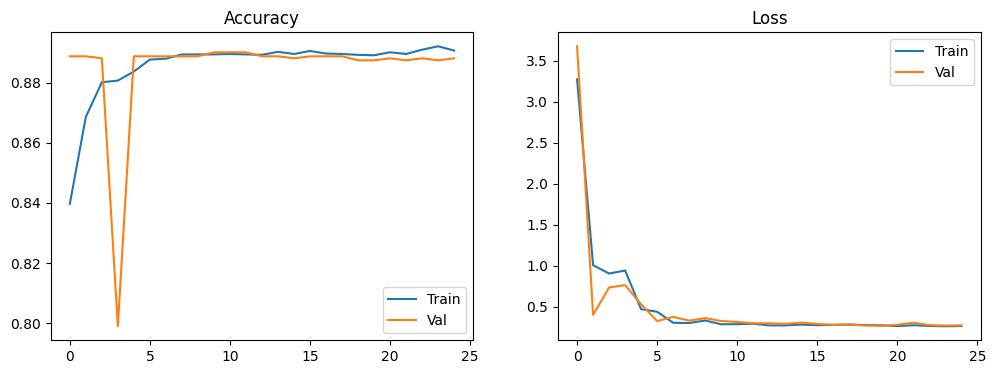

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


In [31]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.8902 - loss: 0.2725
Test Accuracy: 0.8902195692062378


In [26]:
preds = model.predict(test_generator)
pred_labels = (preds > 0.5).astype(int).ravel()

true_labels = test_generator.classes

print(classification_report(true_labels, pred_labels))


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1336
           1       1.00      0.01      0.02       167

    accuracy                           0.89      1503
   macro avg       0.95      0.51      0.48      1503
weighted avg       0.90      0.89      0.84      1503

